# Clustering (KMeans VS DBSCAN) - Customer Personality Analysis 🔎🤷‍♂️

## ℹ  About Dataset

Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.

## 🔑 Key Features

* **ID** : Customer's unique identifier
* **Year_Birth** : Customer's birth year
* **Education** : Customer's education level
* **Marital_Status** : Customer's marital status
* **Income** : Customer's yearly household income
* **Kidhome** : Number of children in customer's household
* **Teenhome** : Number of teenagers in customer's household
* **Dt_Customer** : Date of customer's enrollment with the company
* **Recency** : Number of days since customer's last purchase
* **Complain** : 1 if the customer complained in the last 2 years, 0 otherwise

* **MntWines** : Amount spent on wine in last 2 years
* **MntFruits** : Amount spent on fruits in last 2 years
* **MntMeatProducts** : Amount spent on meat in last 2 years
* **MntFishProducts** : Amount spent on fish in last 2 years
* **MntSweetProducts** : Amount spent on sweets in last 2 years
* **MntGoldProds** : Amount spent on gold in last 2 years

* **NumDealsPurchases** : Number of purchases made with a discount
* **AcceptedCmp1** : 1 if customer accepted the offer in the 1st campaign, 0 otherwise
* **AcceptedCmp2** : 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
* **AcceptedCmp3** : 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
* **AcceptedCmp4** : 1 if customer accepted the offer in the 4th campaign, 0 otherwise
* **AcceptedCmp5** : 1 if customer accepted the offer in the 5th campaign, 0 otherwise
* **Response** : 1 if customer accepted the offer in the last campaign, 0 otherwise

* **NumWebPurchases** : Number of purchases made through the company’s website
* **NumCatalogPurchases** : Number of purchases made using a catalogue
* **NumStorePurchases** : Number of purchases made directly in stores
* **NumWebVisitsMonth** : Number of visits to company’s website in the last month

## 🎯 Target
* Need to perform clustering to summarize customer segments.

In [1]:
! pip install -q kaggle

In [2]:
import os
os.makedirs("/root/.kaggle" , exist_ok=True)
!cp drive/MyDrive/Colab\ Notebooks/Kaggle/kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d imakash3011/customer-personality-analysis

Dataset URL: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
License(s): CC0-1.0
customer-personality-analysis.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Unzip the uploaded data into Google Drive
!unzip -q mall-customers-segmentation.zip

unzip:  cannot find or open mall-customers-segmentation.zip, mall-customers-segmentation.zip.zip or mall-customers-segmentation.zip.ZIP.


In [6]:
import pandas as pd
import random

customer_data = pd.read_csv("/content/customer-personality-analysis.zip" , sep="\t")
customer_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
# Information about dataset
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
# Check for null values
customer_data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [9]:
# Fill Income null values with mean
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())

In [10]:
# Identify object values
for col in customer_data.columns :
    if customer_data[col].dtypes == 'object' :
        print(col)

Education
Marital_Status
Dt_Customer


In [11]:
education_unique = customer_data['Education'].unique()
customer_data['Education'] = [ ((e == education_unique).astype(int)).argmax() for e in customer_data['Education']]
marital_unique = customer_data['Marital_Status'].unique()
customer_data['Marital_Status'] = [ ((m == marital_unique).astype(int)).argmax() for m in customer_data['Marital_Status']]
customer_unique = customer_data['Dt_Customer'].unique()
customer_data.drop('Dt_Customer' , axis=1);

In [12]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   int64  
 3   Marital_Status       2240 non-null   int64  
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [13]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Select relevant data for clustering & interpretation

# Numeric Features
numeric_features = [
    'Income', 'Recency',
    'MntWines', 'MntMeatProducts',
    'NumWebPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]

# Encoded Features
categorical_features = ['Education', 'Marital_Status']

# Create Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num' , StandardScaler() , numeric_features),
        ('pass' , 'passthrough' , categorical_features)
])

X_transformed = preprocessor.fit_transform(customer_data)

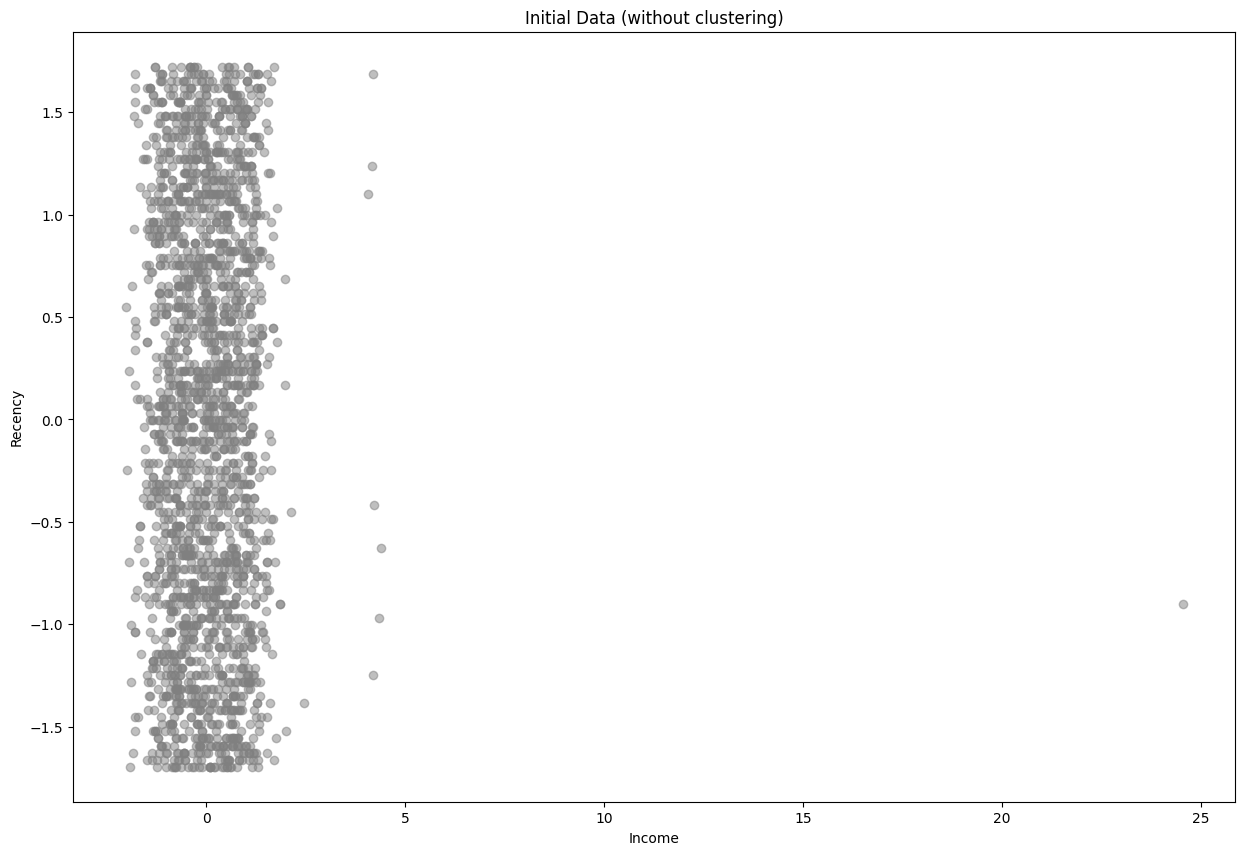

In [49]:
# Plot initial data
import matplotlib.pyplot as plt
import seaborn as sns

X_plot = X_transformed[: , :2]

plt.figure(figsize=(15,10))
plt.scatter(X_plot[:,0] , X_plot[:,1] , c='gray' , alpha=0.5)
plt.title("Initial Data (without clustering)")
plt.xlabel("Income")
plt.ylabel("Recency")
plt.show()

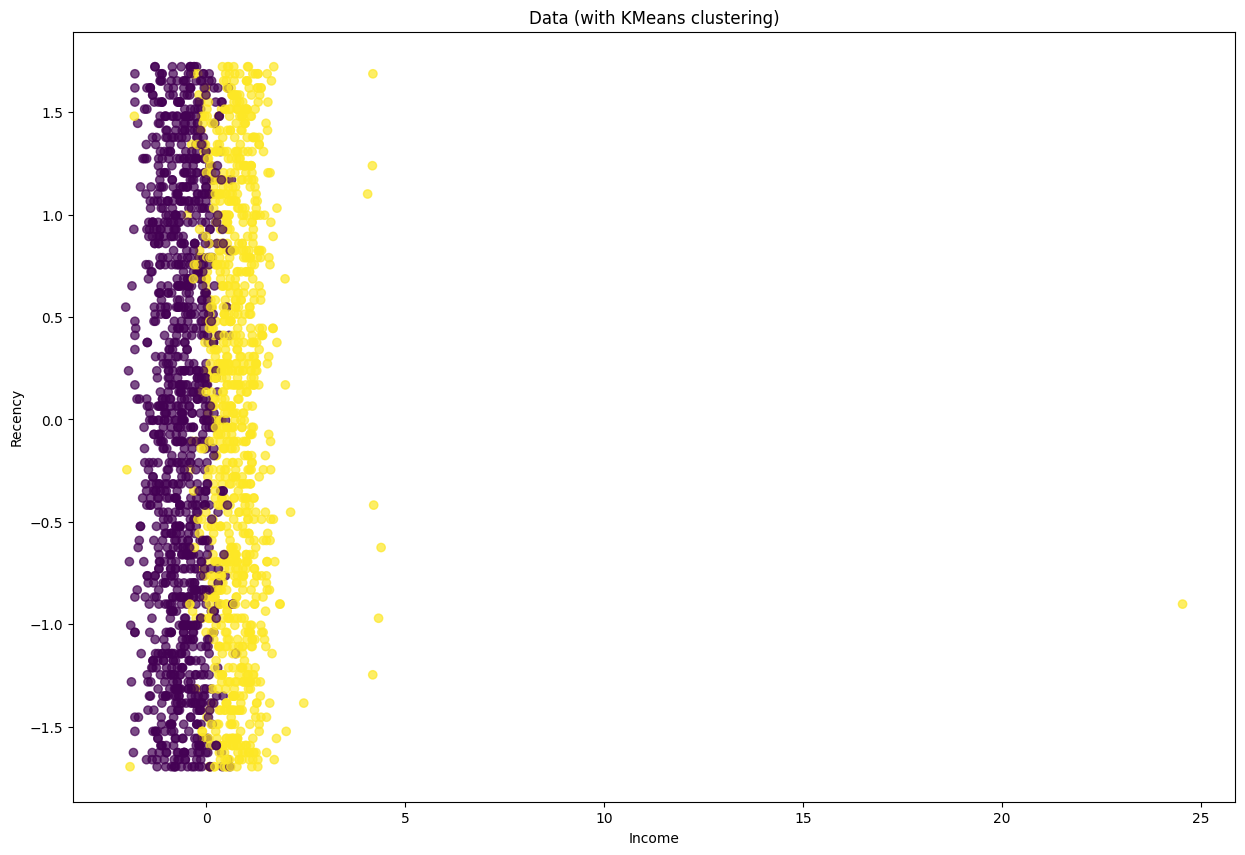

In [56]:
from sklearn.cluster import KMeans, DBSCAN

# KMeans - clustering
kmeans = KMeans(n_clusters=2 , random_state=42)
clusters_kmeans = kmeans.fit_predict(X_transformed)
labels_kmeans = kmeans.labels_

# Plot KMeans
plt.figure(figsize=(15,10))
plt.scatter(X_plot[:,0] , X_plot[:,1] , c=clusters_kmeans , cmap='viridis' , alpha=0.7)
plt.title("Data (with KMeans clustering)")
plt.xlabel("Income")
plt.ylabel("Recency")
plt.show()

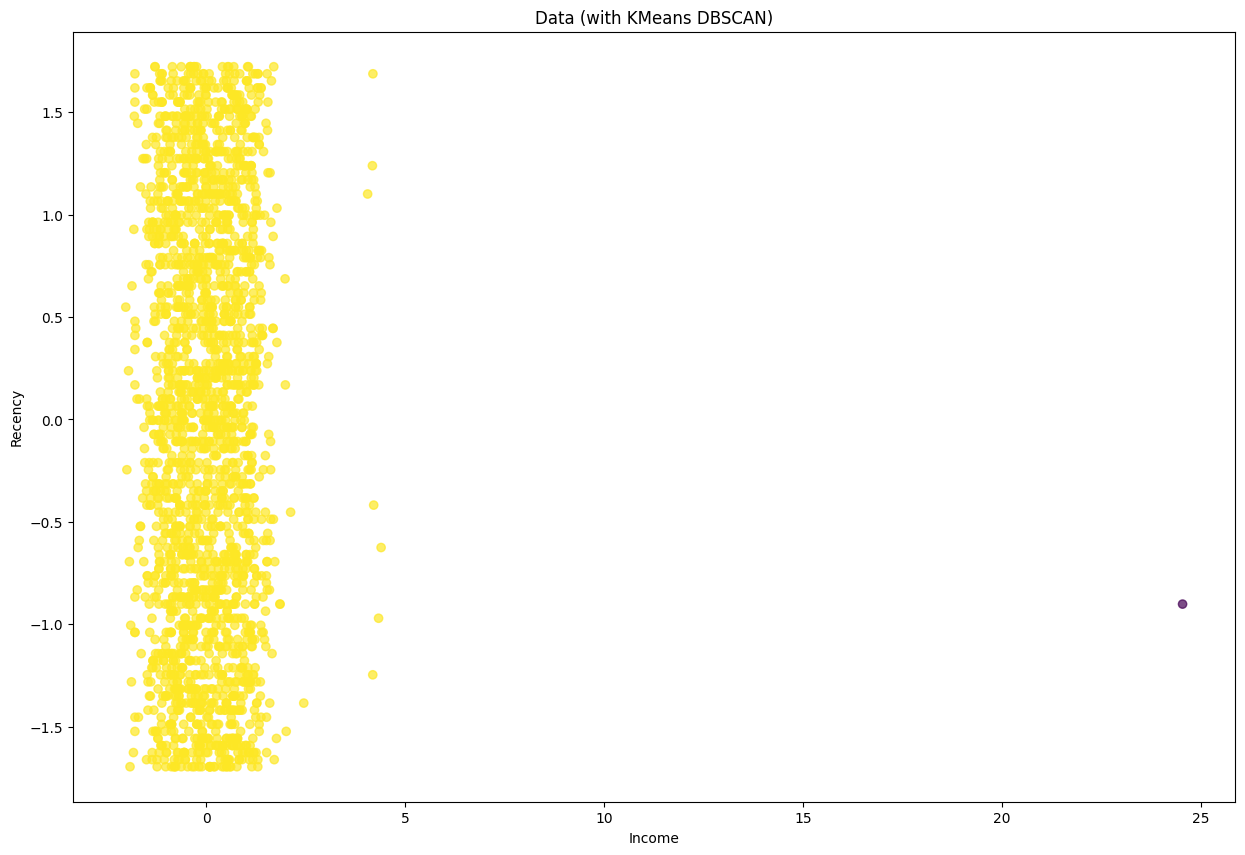

In [57]:
# DBSCAN - clustering
dbscan = DBSCAN(eps=8.0 , min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_transformed)
labels_dbscan = dbscan.labels_

# Plot DBSCAN

plt.figure(figsize=(15,10))
plt.scatter(X_plot[:,0] , X_plot[:,1] , c=clusters_dbscan , cmap='viridis' , alpha=0.7)
plt.title("Data (with KMeans DBSCAN)")
plt.xlabel("Income")
plt.ylabel("Recency")
plt.show()

In [55]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X, labels, name):
    print(f"\n{name} Evaluation:")
    print("Silhouette Score:", silhouette_score(X, labels))

evaluate_clustering(X_transformed, labels_kmeans, "KMeans")
evaluate_clustering(X_transformed, labels_dbscan, "DBSCAN")


KMeans Evaluation:
Silhouette Score: 0.1562873300454696

DBSCAN Evaluation:
Silhouette Score: 0.8330200850007912
